### Data Preprocessing

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [26]:
df = pd.read_csv("ai_job_replacement_2020_2026_v2.csv")

print(df.head())
print(df.info())

   job_id              job_role       industry country  year  \
0       0          Data Analyst     Technology  Canada  2021   
1       1            Accountant        Finance  Brazil  2020   
2       2               Teacher     Technology     USA  2020   
3       3  Customer Support Rep     Technology  Brazil  2021   
4       4               Teacher  Manufacturing   Japan  2024   

   automation_risk_percent  ai_replacement_score  skill_gap_index  \
0                    26.22                 30.94            73.20   
1                    52.08                 56.41             2.06   
2                    31.30                 31.61            43.19   
3                    56.92                 63.42            19.97   
4                    14.55                 17.17            96.56   

   salary_before_usd  salary_after_usd  salary_change_percent  \
0          101839.02          99454.42                  -2.34   
1          146389.18         139516.59                  -4.69   
2    

1. Data Cleaning

In [27]:
# Check missing values
print(df.isnull().sum())

# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

print("Cleaned dataset shape:", df.shape)

job_id                         0
job_role                       0
industry                       0
country                        0
year                           0
automation_risk_percent        0
ai_replacement_score           0
skill_gap_index                0
salary_before_usd              0
salary_after_usd               0
salary_change_percent          0
skill_demand_growth_percent    0
remote_feasibility_score       0
ai_adoption_level              0
education_requirement_level    0
automation_risk_category       0
skill_transition_pressure      0
wage_volatility_index          0
reskilling_urgency_score       0
ai_disruption_intensity        0
dtype: int64
Cleaned dataset shape: (15000, 20)


2. Feature Creation

In [28]:
df["salary_change"] = df["salary_after_usd"] - df["salary_before_usd"]

3. Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# List of categorical columns to convert into numeric labels
categorical_columns = [
    "job_role",
    "industry",
    "country",
    "ai_adoption_level",
    "automation_risk_category"
]


for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
    # Converts text labels to numeric values, e.g., 'Low' -> 0, 'High' -> 2

4. Sample Data Visualization

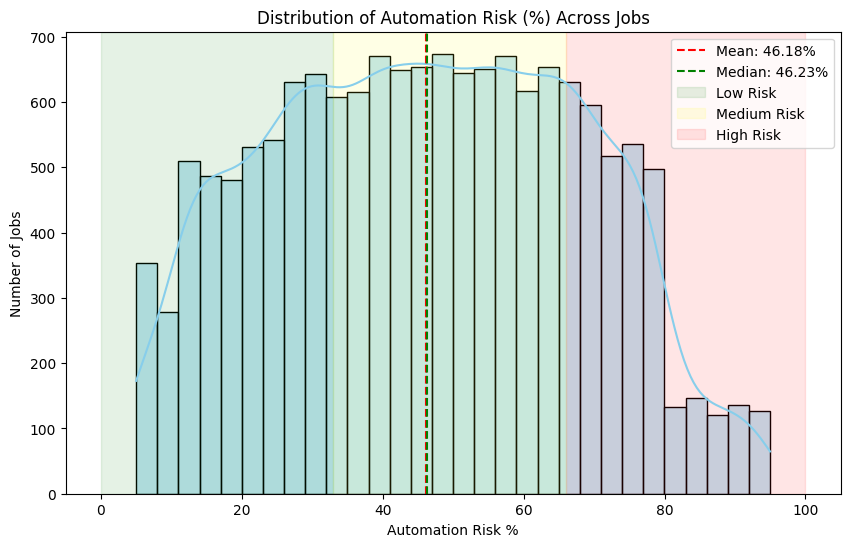

In [36]:
plt.figure(figsize=(10,6))

# Plot histogram with 30 bins and KDE for smooth curve
sns.histplot(df["automation_risk_percent"], bins=30, kde=True, color="skyblue")

# Add vertical lines for mean and median
mean_risk = df["automation_risk_percent"].mean()
median_risk = df["automation_risk_percent"].median()

plt.axvline(mean_risk, color='red', linestyle='--', label=f"Mean: {mean_risk:.2f}%")
plt.axvline(median_risk, color='green', linestyle='--', label=f"Median: {median_risk:.2f}%")

# Optional: highlight risk categories (Low, Medium, High)
plt.axvspan(0, 33, color='green', alpha=0.1, label='Low Risk')
plt.axvspan(33, 66, color='yellow', alpha=0.1, label='Medium Risk')
plt.axvspan(66, 100, color='red', alpha=0.1, label='High Risk')

# Add labels and title
plt.title("Distribution of Automation Risk (%) Across Jobs")
plt.xlabel("Automation Risk %")
plt.ylabel("Number of Jobs")
plt.legend()

# Show the plot
plt.show()